In [1]:
# ── 1. Install ────────────────────────────────────────────────────────────────
!pip install unsloth trl>=0.24.0 peft accelerate datasets huggingface_hub -q
!pip install git+https://github.com/Ankitpatil944/blackout-city.git -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── 2. C compiler (required by Triton) ───────────────────────────────────────
import subprocess, os, shutil

if not shutil.which("gcc"):
    subprocess.run(["apt-get", "install", "-y", "-q", "gcc"], check=True)
os.environ["CC"] = shutil.which("gcc") or "gcc"
print("CC =", os.environ["CC"])

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  binutils binutils-common binutils-x86-64-linux-gnu cpp cpp-14
  cpp-14-x86-64-linux-gnu cpp-x86-64-linux-gnu gcc-14 gcc-14-x86-64-linux-gnu
  gcc-x86-64-linux-gnu libasan8 libatomic1 libbinutils libc-dev-bin libc6-dev
  libcc1-0 libcrypt-dev libctf-nobfd0 libctf0 libgcc-14-dev libgomp1
  libgprofng0 libhwasan0 libisl23 libitm1 libjansson4 liblsan0 libmpc3
  libmpfr6 libquadmath0 libsframe1 libtsan2 libubsan1 linux-libc-dev manpages
  manpages-dev rpcsvc-proto
Suggested packages:
  binutils-doc gprofng-gui binutils-gold cpp-doc gcc-14-locales cpp-14-doc
  gcc-multilib make autoconf automake libtool flex bison gdb gcc-doc
  gcc-14-multilib gcc-14-doc gdb-x86-64-linux-gnu libc-devtools glibc-doc
  man-browser
The following NEW packages will be installed:
  binutils binutils-common binutils-x86-64-linux-gnu cpp cpp-14
  cpp-14-x86-64-linux-gnu cpp-x86-64-

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 38.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
debconf: unable to initialize frontend: Teletype
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Noninteractive


Fetched 60.4 MB in 0s (278 MB/s)
Selecting previously unselected package manpages.
(Reading database ... 9639 files and directories currently installed.)
Preparing to unpack .../00-manpages_6.9.1-1_all.deb ...
Unpacking manpages (6.9.1-1) ...
Selecting previously unselected package libsframe1:amd64.
Preparing to unpack .../01-libsframe1_2.44-3_amd64.deb ...
Unpacking libsframe1:amd64 (2.44-3) ...
Selecting previously unselected package binutils-common:amd64.
Preparing to unpack .../02-binutils-common_2.44-3_amd64.deb ...
Unpacking binutils-common:amd64 (2.44-3) ...
Selecting previously unselected package libbinutils:amd64.
Preparing to unpack .../03-libbinutils_2.44-3_amd64.deb ...
Unpacking libbinutils:amd64 (2.44-3) ...
Selecting previously unselected package libgprofng0:amd64.
Preparing to unpack .../04-libgprofng0_2.44-3_amd64.deb ...
Unpacking libgprofng0:amd64 (2.44-3) ...
Selecting previously unselected package libctf-nobfd0:amd64.
Preparing to unpack .../05-libctf-nobfd0_2.44-3

In [3]:
# ── 3. Patch Unsloth dtype bugs ───────────────────────────────────────────────
# Must run on every fresh runtime before loading any model.
# Fixes: Half/Float mismatches in matmul_lora, LoRA_MLP.backward, LoRA_W.backward

import re, importlib

# ── utils.py: rewrite matmul_lora to be dtype-safe ───────────────────────────
# Strategy: replace the entire matmul_lora function body with a safe version.
# The key fix: out is None by default; only cast it AFTER it is computed.
utils_path = "/usr/local/lib/python3.10/site-packages/unsloth/kernels/utils.py"
with open(utils_path) as f:
    src = f.read()

SAFE_MATMUL_LORA = '''
def matmul_lora(X, W, W_quant, A, B, s, out = None):
    # Matches unsloth layout: W is (out, in) like nn.Linear; LoRA A,B are transposed in-place.
    if X.dim() == 3:
        batch, seq_len, d = X.shape
        X = X.view(-1, d)
        reshape = True
    else:
        reshape = False

    if W_quant is None:
        out = torch.matmul(X, W.t(), out=out)
    else:
        out = fast_dequantize(W.t(), W_quant)
        out = torch.matmul(X, out)

    d = torch.get_autocast_gpu_dtype() if torch.is_autocast_enabled() else out.dtype
    out = out.to(d)

    if A is not None:
        A, B = A.t(), B.t()
        XA = torch.matmul(X, A.to(d))
        out.addmm_(XA, B.to(d), alpha=s)

    return out.view(batch, seq_len, -1) if reshape else out
'''

# Use regex to replace the entire matmul_lora function (handles any prior patched state)
pattern = r'def matmul_lora\(X,\s*W,\s*W_quant,\s*A,\s*B,\s*s,\s*out\s*=\s*None\):.*?(?=\ndef |\nclass |\Z)'
if re.search(pattern, src, re.DOTALL):
    src = re.sub(pattern, SAFE_MATMUL_LORA.strip(), src, count=1, flags=re.DOTALL)
    print('utils.py  ✓ matmul_lora fully rewritten (dtype-safe)')
else:
    print('utils.py  ✗ matmul_lora not found — check manually')

with open(utils_path, 'w') as f:
    f.write(src)

# ── fast_lora.py: fix LoRA_MLP.backward and LoRA_W.backward dtype handling ───
lora_path = "/usr/local/lib/python3.10/site-packages/unsloth/kernels/fast_lora.py"
with open(lora_path) as f:
    src = f.read()

patches = [
    # LoRA_MLP backward — define _cd from autocast dtype
    ("        dtype = X.dtype\n\n        gateA, gateB, upA, upB, downA, downB = (",
     "        _cd   = torch.get_autocast_gpu_dtype() if torch.is_autocast_enabled() else gateA.dtype\n        dtype = _cd\n        X     = X.to(_cd)\n        dY    = dY.to(_cd)\n\n        gateA, gateB, upA, upB, downA, downB = ("),
    ("        dtype = gateA.dtype\n        X     = X.to(dtype)\n        dY    = dY.to(dtype)\n",
     "        _cd   = torch.get_autocast_gpu_dtype() if torch.is_autocast_enabled() else gateA.dtype\n        dtype = _cd\n        X     = X.to(_cd)\n        dY    = dY.to(_cd)\n"),
    # LoRA_MLP backward — empty_like → explicit dtype
    ("        d_downA = torch.empty_like(downA)\n        d_downB = torch.empty_like(downB)\n        d_gateA = torch.empty_like(gateA)\n        d_gateB = torch.empty_like(gateB)\n        d_upA = torch.empty_like(upA)\n        d_upB = torch.empty_like(upB)\n",
     "        d_downA = torch.empty(downA.shape, dtype=_cd, device=downA.device)\n        d_downB = torch.empty(downB.shape, dtype=_cd, device=downB.device)\n        d_gateA = torch.empty(gateA.shape, dtype=_cd, device=gateA.device)\n        d_gateB = torch.empty(gateB.shape, dtype=_cd, device=gateB.device)\n        d_upA   = torch.empty(upA.shape,   dtype=_cd, device=upA.device)\n        d_upB   = torch.empty(upB.shape,   dtype=_cd, device=upB.device)\n"),
    # LoRA_MLP backward — remove old _bd cast block
    ("        # Force dtype consistency for all backward tensors\n        _bd = d_downA.dtype\n        h = h.to(_bd); dY = dY.to(_bd); df = df.to(_bd); de = de.to(_bd)\n        X = X.to(_bd)\n        downA = downA.to(_bd); downB = downB.to(_bd)\n        upA   = upA.to(_bd);   upB   = upB.to(_bd)\n        gateA = gateA.to(_bd); gateB = gateB.to(_bd)\n\n",
     "        h  = h.to(_cd);  df = df.to(_cd);  de = de.to(_cd)\n\n"),
    # LoRA_MLP backward — cast fast_dequantize outputs
    ("        upW = fast_dequantize(upW.t(), upW_quant)\n        dX = torch.matmul(df, upW.t(), out = X if ctx.inplace else None)\n",
     "        upW = fast_dequantize(upW.t(), upW_quant).to(_cd)\n        dX  = torch.matmul(df, upW.t(), out = X.to(_cd) if ctx.inplace else None)\n"),
    ("        gateW = fast_dequantize(gateW.t(), gateW_quant)\n",
     "        gateW = fast_dequantize(gateW.t(), gateW_quant).to(_cd)\n"),
    # LoRA_W backward — define _cd
    ("        dY = dY.reshape(-1, dY.shape[-1])  # Must be reshape\n        X = X.reshape(-1, X.shape[-1])  # Must be reshape\n        dtype = X.dtype\n",
     "        dY = dY.reshape(-1, dY.shape[-1])  # Must be reshape\n        X = X.reshape(-1, X.shape[-1])  # Must be reshape\n        _cd  = torch.get_autocast_gpu_dtype() if torch.is_autocast_enabled() else X.dtype\n        dtype = _cd\n        X    = X.to(_cd)\n        dY   = dY.to(_cd)\n"),
    # LoRA_W backward — empty_like
    ("        d_A = torch.empty_like(A)\n        d_B = torch.empty_like(B)\n",
     "        d_A = torch.empty(A.shape, dtype=_cd, device=A.device)\n        d_B = torch.empty(B.shape, dtype=_cd, device=B.device)\n"),
    # LoRA_W backward — cast fast_dequantize
    ("        W = fast_dequantize(W.t(), W_quant)\n        dX = dY @ W.t()\n",
     "        W  = fast_dequantize(W.t(), W_quant).to(_cd)\n        dX = dY @ W.t()\n"),
]

n = sum(1 for old, new in patches if old in src and src.__setattr__ or src.count(old) > 0)
applied = []
for old, new in patches:
    if old in src:
        src = src.replace(old, new, 1)
        applied.append(True)

with open(lora_path, "w") as f:
    f.write(src)

already = src.count("_cd   = torch.get_autocast_gpu_dtype")
print(f"fast_lora.py  ✓ {len(applied)} patches applied (already-patched lines skipped)")

# Reload both modules so patches are live without kernel restart
import importlib
import unsloth.kernels.utils as _ku; importlib.reload(_ku)
import unsloth.kernels.fast_lora as _fl; importlib.reload(_fl)
print("\n✓ Modules reloaded. All patches active. Continue to next cell.")

utils.py  ✓ matmul_lora fully rewritten (dtype-safe)
fast_lora.py  ✓ 7 patches applied (already-patched lines skipped)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!

✓ Modules reloaded. All patches active. Continue to next cell.


In [4]:
# ── 4. Download SFT adapter + dataset from HF Space ──────────────────────────
import os, shutil
from huggingface_hub import snapshot_download, hf_hub_download

HF_SPACE = "SidditaVarma/Built-different"
SFT_DIR  = "sft_adapter"
DATASET  = "dataset_train.jsonl"

if not os.path.isdir(SFT_DIR):
    snapshot_download(
        repo_id        = HF_SPACE,
        repo_type      = "space",
        allow_patterns = ["latest/blackstart-city-sft/**"],
        local_dir      = ".",
    )
    shutil.move("latest/blackstart-city-sft", SFT_DIR)
    print(f"Downloaded SFT adapter → {SFT_DIR}/")
else:
    print(f"Reusing existing {SFT_DIR}/")

if not os.path.isfile(DATASET):
    hf_hub_download(
        repo_id   = HF_SPACE,
        repo_type = "space",
        filename  = "latest/dataset_train.jsonl",
        local_dir = ".",
    )
    shutil.move("latest/dataset_train.jsonl", DATASET)
    print(f"Downloaded dataset → {DATASET}")
else:
    print(f"Reusing existing {DATASET}")

import subprocess
print(subprocess.run(["ls", "-lh", SFT_DIR], capture_output=True, text=True).stdout)

Fetching 28 files: 100%|██████████| 28/28 [00:01<00:00, 14.40it/s]


Downloaded SFT adapter → sft_adapter/
Downloaded dataset → dataset_train.jsonl
total 126M
-rw-r--r--. 1 root root 1.6K Apr 26 09:13 README.md
-rw-r--r--. 1 root root 1.3K Apr 26 09:13 adapter_config.json
-rw-r--r--. 1 root root 115M Apr 26 09:13 adapter_model.safetensors
-rw-r--r--. 1 root root 2.5K Apr 26 09:13 chat_template.jinja
drwxr-sr-x. 2 root root 4.0K Apr 26 09:13 checkpoint-100
drwxr-sr-x. 2 root root 4.0K Apr 26 09:13 checkpoint-200
-rw-r--r--. 1 root root  11M Apr 26 09:13 tokenizer.json
-rw-r--r--. 1 root root 4.5K Apr 26 09:13 tokenizer_config.json



In [5]:
# ── 5. Load base model + SFT adapter ─────────────────────────────────────────
import json, torch
from unsloth import FastLanguageModel, PatchFastRL, is_bfloat16_supported

PatchFastRL("GRPO", FastLanguageModel)

COMPUTE_DTYPE = torch.bfloat16 if is_bfloat16_supported() else torch.float16

cfg = json.load(open(f"{SFT_DIR}/adapter_config.json"))
BASE_MODEL = cfg["base_model_name_or_path"]
print("Base model :", BASE_MODEL)
print("Adapter r  :", cfg.get("r"))
print("LoRA alpha :", cfg.get("lora_alpha"))

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name             = BASE_MODEL,
    max_seq_length         = 4096,
    load_in_4bit           = True,
    fast_inference         = False,
    max_lora_rank          = 16,
    gpu_memory_utilization = 0.6,
)
model.warnings_issued = {}

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj","k_proj","v_proj","o_proj",
                      "gate_proj","up_proj","down_proj"],
    lora_alpha     = 32,
    use_gradient_checkpointing = "unsloth",
    random_state   = 3407,
)

model.load_adapter(SFT_DIR, adapter_name="sft_init", is_trainable=True, autocast_adapter_dtype=False)
model.set_adapter("sft_init")

# Cast all LoRA weights to compute dtype
for module in model.modules():
    for attr in ("lora_A", "lora_B"):
        d = getattr(module, attr, None)
        if isinstance(d, torch.nn.ModuleDict):
            for layer in d.values():
                if hasattr(layer, "weight") and layer.weight is not None:
                    layer.weight.data = layer.weight.data.to(COMPUTE_DTYPE)

print("Compute dtype :", COMPUTE_DTYPE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.
Base model : unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit
Adapter r  : 16
LoRA alpha : 32
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L40S. Num GPUs = 1. Max memory: 44.392 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. 

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 1041.50it/s]


unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Compute dtype : torch.bfloat16
Trainable params: 29933568


In [6]:
# ── 6. Load, split & format dataset ──────────────────────────────────────────
from datasets import load_dataset

raw    = load_dataset("json", data_files=DATASET, split="train")
splits = raw.train_test_split(test_size=0.1, seed=42)

def to_chat(example):
    return {"prompt": [
        {"role": "system",  "content": "You are a city blackout restoration policy. "
                                       "Return exactly one valid JSON action object and nothing else."},
        {"role": "user",    "content": "Observation:\n" + example["prompt"]},
    ]}

train_dataset = splits["train"].map(to_chat, remove_columns=splits["train"].column_names)
test_dataset  = splits["test"].map(to_chat,  remove_columns=splits["test"].column_names)

print(f"Train: {len(train_dataset)} examples")
print(f"Test : {len(test_dataset)}  examples")

Generating train split: 1854 examples [00:00, 74827.66 examples/s]
Map: 100%|██████████| 186/186 [00:00<00:00, 12164.04 examples/s]

Train: 1668 examples
Test : 186  examples


In [7]:
from blackstart_city.training.grpo_train import (
    format_reward_func,
    alignment_reward_func,
    action_quality_reward_func,
    constraint_reward_func,
    failure_context_reward_func,
)
print("Reward functions loaded.")

Reward functions loaded.


In [8]:
# ── 8. GRPO config + trainer ──────────────────────────────────────────────────
from trl import GRPOConfig, GRPOTrainer

MAX_STEPS  = 500
OUTPUT_DIR = "grpo_output"

training_args = GRPOConfig(
    output_dir                  = OUTPUT_DIR,
    learning_rate               = 5e-6,
    lr_scheduler_type           = "cosine",
    max_steps                   = MAX_STEPS,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 2,
    num_generations             = 8,
    generation_batch_size       = 8,
    max_prompt_length           = 3500,
    max_completion_length       = 150,
    temperature                 = 0.9,
    bf16                        = is_bfloat16_supported(),
    fp16                        = not is_bfloat16_supported(),
    optim                       = "adamw_8bit",
    logging_steps               = 5,
    report_to                   = "none",
)

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = [
        format_reward_func,
        alignment_reward_func,
        action_quality_reward_func,
        constraint_reward_func,
        failure_context_reward_func,
    ],
    reward_weights   = [0.2, 0.2, 0.2, 0.2, 0.2],
    args             = training_args,
    train_dataset    = train_dataset,
    eval_dataset     = test_dataset,
)
print("Trainer ready.")

Trainer ready.


In [9]:
import subprocess, shutil, os, torch

# Install g++ if missing
if not shutil.which("g++"):
    subprocess.run(["apt-get", "install", "-y", "-q", "g++"], check=True)
    print("g++ installed")
else:
    print("g++ already present:", shutil.which("g++"))

# Tell Inductor where it is
gpp = shutil.which("g++")
os.environ["CXX"] = gpp
os.environ["CC"]  = shutil.which("gcc") or "gcc"
torch._inductor.config.cpp.cxx = (gpp,)
print("Inductor CXX set to:", torch._inductor.config.cpp.cxx)

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  g++-14 g++-14-x86-64-linux-gnu g++-x86-64-linux-gnu libstdc++-14-dev
Suggested packages:
  g++-multilib g++-14-multilib gcc-14-doc libstdc++-14-doc
The following NEW packages will be installed:
  g++ g++-14 g++-14-x86-64-linux-gnu g++-x86-64-linux-gnu libstdc++-14-dev
0 upgraded, 5 newly installed, 0 to remove and 0 not upgraded.
Need to get 14.5 MB of archives.
After this operation, 60.5 MB of additional disk space will be used.
Get:1 http://deb.debian.org/debian trixie/main amd64 libstdc++-14-dev amd64 14.2.0-19 [2376 kB]
Get:2 http://deb.debian.org/debian trixie/main amd64 g++-14-x86-64-linux-gnu amd64 14.2.0-19 [12.1 MB]
Get:3 http://deb.debian.org/debian trixie/main amd64 g++-14 amd64 14.2.0-19 [22.5 kB]
Get:4 http://deb.debian.org/debian trixie/main amd64 g++-x86-64-linux-gnu amd64 4:14.2.0-1 [1200 B]
Get:5 http://deb.debian.org/debian trixie/ma

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 5.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
debconf: unable to initialize frontend: Teletype
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Noninteractive


Fetched 14.5 MB in 0s (238 MB/s)
Selecting previously unselected package libstdc++-14-dev:amd64.
(Reading database ... 16611 files and directories currently installed.)
Preparing to unpack .../libstdc++-14-dev_14.2.0-19_amd64.deb ...
Unpacking libstdc++-14-dev:amd64 (14.2.0-19) ...
Selecting previously unselected package g++-14-x86-64-linux-gnu.
Preparing to unpack .../g++-14-x86-64-linux-gnu_14.2.0-19_amd64.deb ...
Unpacking g++-14-x86-64-linux-gnu (14.2.0-19) ...
Selecting previously unselected package g++-14.
Preparing to unpack .../g++-14_14.2.0-19_amd64.deb ...
Unpacking g++-14 (14.2.0-19) ...
Selecting previously unselected package g++-x86-64-linux-gnu.
Preparing to unpack .../g++-x86-64-linux-gnu_4%3a14.2.0-1_amd64.deb ...
Unpacking g++-x86-64-linux-gnu (4:14.2.0-1) ...
Selecting previously unselected package g++.
Preparing to unpack .../g++_4%3a14.2.0-1_amd64.deb ...
Unpacking g++ (4:14.2.0-1) ...
Setting up libstdc++-14-dev:amd64 (14.2.0-19) ...
Setting up g++-14-x86-64-linux-

In [10]:
# ── 9. Train ──────────────────────────────────────────────────────────────────
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,668 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 29,933,568 of 3,145,805,824 (0.95% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` w

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / alignment_reward_func / mean,rewards / alignment_reward_func / std,rewards / action_quality_reward_func / mean,rewards / action_quality_reward_func / std,rewards / constraint_reward_func / mean,rewards / constraint_reward_func / std,rewards / failure_context_reward_func / mean,rewards / failure_context_reward_func / std
5,-0.095216,1.926344,1.099780,21.250000,18.500000,25.500000,0.000000,21.250000,18.500000,25.500000,1.293530,0.968750,0.088388,0.178125,0.267741,0.226938,0.298098,0.565031,0.252510,-0.012500,0.511906
10,0.101115,3.000000,0.000000,22.875000,22.000000,24.000000,0.000000,22.875000,22.000000,24.000000,0.987897,1.000000,0.000000,0.500000,0.534522,0.500000,0.534522,0.500000,0.000000,0.500000,0.000000
15,0.000799,2.000000,0.000000,27.000000,27.000000,27.000000,0.000000,27.000000,27.000000,27.000000,0.798988,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000
20,0.000937,3.000000,0.000000,21.000000,21.000000,21.000000,0.000000,21.000000,21.000000,21.000000,0.937126,1.000000,0.000000,0.875000,0.353553,0.125000,0.353553,0.500000,0.000000,0.500000,0.000000
25,-0.089541,1.813750,1.330352,24.937500,23.000000,29.000000,0.000000,24.937500,23.000000,29.000000,0.963314,0.950000,0.141421,0.425000,0.541301,0.098750,0.258039,0.440000,0.169706,-0.100000,0.476550
30,0.069448,2.437500,1.208231,20.625000,19.000000,22.000000,0.000000,20.625000,19.000000,22.000000,1.101089,1.000000,0.000000,0.500000,0.534522,0.250000,0.462910,0.562500,0.176777,0.125000,0.694365
35,-0.089323,3.125000,0.231455,20.500000,19.000000,21.000000,0.000000,20.500000,19.000000,21.000000,0.936130,1.000000,0.000000,0.750000,0.462910,0.250000,0.462910,0.625000,0.231455,0.500000,0.000000
40,0.107477,1.500000,1.253566,25.750000,21.000000,27.000000,0.000000,25.750000,21.000000,27.000000,0.989388,1.000000,0.000000,0.375000,0.517549,0.000000,0.000000,0.375000,0.353553,-0.250000,0.801784
45,-0.069315,2.437500,0.176777,20.375000,19.500000,21.000000,0.000000,20.375000,19.500000,21.000000,1.402069,1.000000,0.000000,0.312500,0.258775,0.125000,0.231455,0.500000,0.000000,0.500000,0.000000
50,0.198822,2.470313,1.307907,21.000000,21.000000,21.000000,0.000000,21.000000,21.000000,21.000000,1.204266,0.937500,0.176777,0.725000,0.511999,0.015625,0.235637,0.379687,0.340295,0.412500,0.247487


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1

TrainOutput(global_step=500, training_loss=0.0008806801990140229, metrics={'train_runtime': 1391.628, 'train_samples_per_second': 0.719, 'train_steps_per_second': 0.359, 'total_flos': 0.0, 'train_loss': 0.0008806801990140229})

In [ ]:
import os
from huggingface_hub import HfApi, login

HF_TOKEN = "hf_wxxxxxxxxxxxxxxxxxxx"

login(token=HF_TOKEN)
api = HfApi()
OUTPUT_DIR = "grpo_output"

upload_files = [
    "adapter_model.safetensors",
    "adapter_config.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "generation_config.json",
    "training_summary.png",
]

for filename in upload_files:
    filepath = f"{OUTPUT_DIR}/{filename}"
    if os.path.exists(filepath):
        api.upload_file(
            path_or_fileobj = filepath,
            path_in_repo    = f"latest/blackstart-city-grpo/{filename}",
            repo_id         = "SidditaVarma/Built-different",
            repo_type       = "space",
            commit_message  = f"GRPO model: {filename}",
        )
        print(f"✓ {filename}")
    else:
        print(f"  skip: {filename}")

print("\nDone → https://huggingface.co/spaces/SidditaVarma/Built-different/tree/main/latest/blackstart-city-grpo")

Processing Files (0 / 0): |          |  0.00B /  0.00B            
Processing Files (1 / 1): 100%|██████████| 59.9MB / 59.9MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


HfHubHTTPError: (Request ID: Root=1-69ede4a1-63d2366c78f41d6e0121e3cc;81758d93-df73-48ee-857d-5932aee058a6)

403 Forbidden: Repository storage limit reached (Max: 1 GB).
Cannot access content at: https://huggingface.co/api/spaces/SidditaVarma/Built-different/commit/main.
Make sure your token has the correct permissions.

Unsloth: Restored added_tokens_decoder metadata in grpo_output/tokenizer_config.json.


Adapter saved → grpo_output/


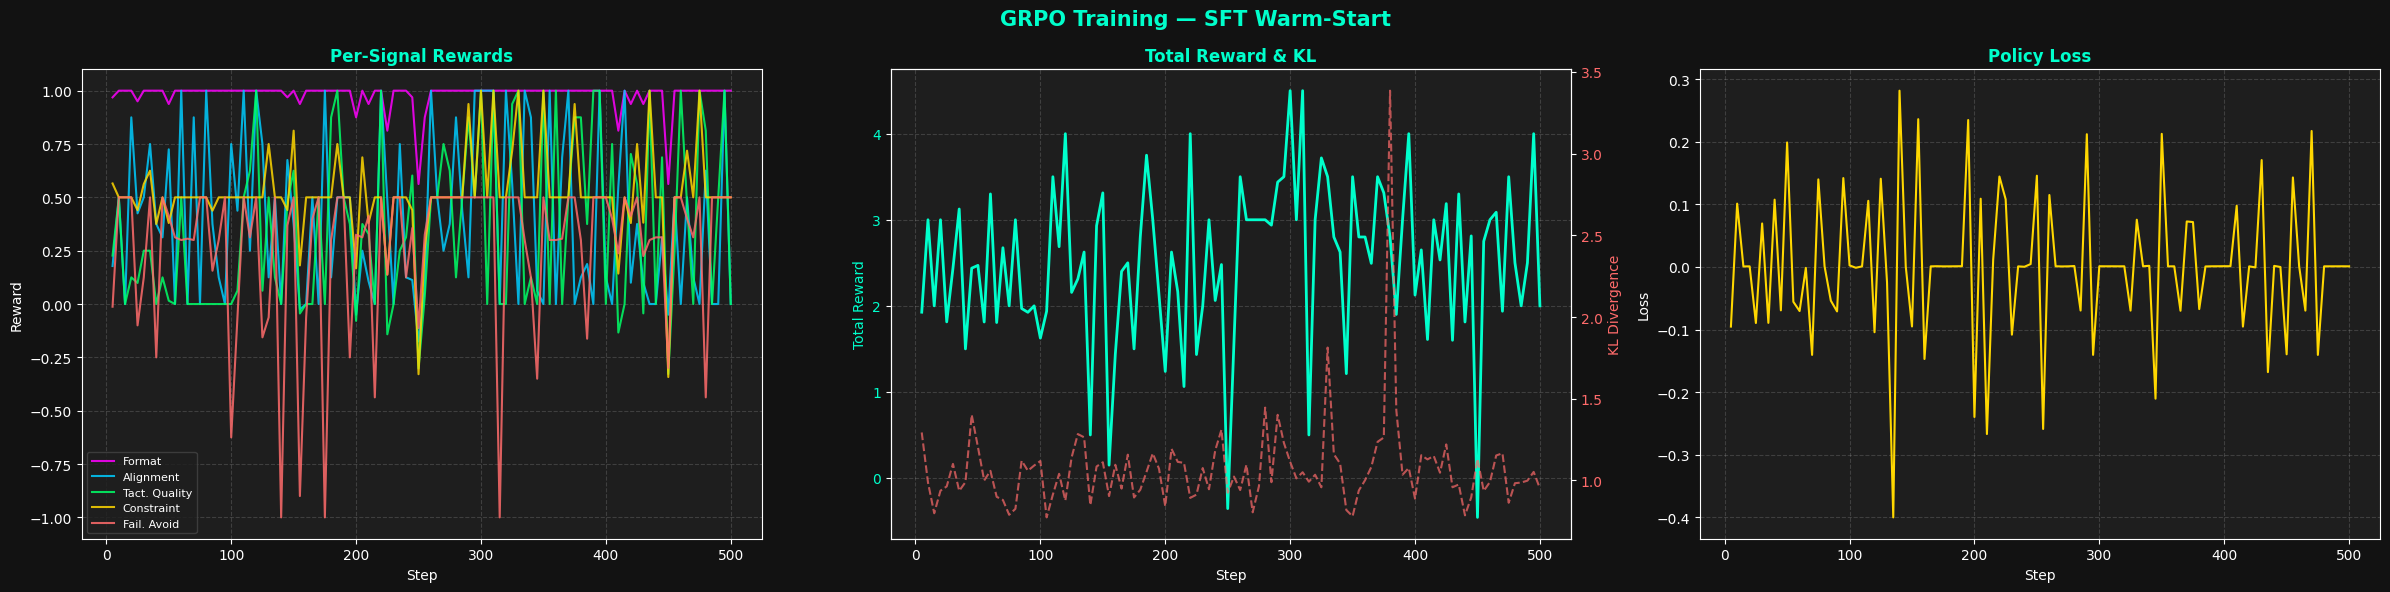

Steps run    : 500
Reward start : 2.3480
Reward end   : 2.6000
Reward change: +0.2520


In [13]:
# ── 10. Save + graphs ─────────────────────────────────────────────────────────
import os, matplotlib.pyplot as plt, numpy as np

model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Adapter saved → {OUTPUT_DIR}/")

def extract(key):
    return [(e["step"], e[key]) for e in trainer.state.log_history if key in e]

steps_rew, total_reward = zip(*extract("reward")) if extract("reward") else ([], [])
steps_kl,  kl_vals      = zip(*extract("kl"))     if extract("kl")     else ([], [])
steps_los, loss_vals    = zip(*extract("loss"))   if extract("loss")   else ([], [])

reward_keys = [
    ("rewards/format_reward_func/mean",          "Format",        "#FF00FF"),
    ("rewards/alignment_reward_func/mean",       "Alignment",     "#00CCFF"),
    ("rewards/action_quality_reward_func/mean",  "Tact. Quality", "#00FF66"),
    ("rewards/constraint_reward_func/mean",      "Constraint",    "#FFD700"),
    ("rewards/failure_context_reward_func/mean", "Fail. Avoid",   "#FF6B6B"),
]

plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(24, 6), facecolor="#121212")
fig.suptitle("GRPO Training — SFT Warm-Start", color="#00FFCC", fontsize=15, fontweight="bold")

ax = axes[0]
ax.set_facecolor("#1e1e1e")
for key, label, color in reward_keys:
    data = extract(key)
    if data:
        xs, ys = zip(*data)
        ax.plot(xs, ys, color=color, linewidth=1.5, alpha=0.85, label=label)
ax.set_title("Per-Signal Rewards", color="#00FFCC", fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.legend(facecolor="#1e1e1e", edgecolor="#444", labelcolor="white", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.15)

ax2 = axes[1]
ax2.set_facecolor("#1e1e1e")
if total_reward:
    ax2.plot(steps_rew, total_reward, color="#00FFCC", linewidth=2)
ax2.set_xlabel("Step"); ax2.set_ylabel("Total Reward", color="#00FFCC")
ax2.tick_params(axis="y", labelcolor="#00FFCC")
ax2.set_title("Total Reward & KL", color="#00FFCC", fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.15)
if kl_vals:
    ax2b = ax2.twinx()
    ax2b.plot(steps_kl, kl_vals, color="#FF6B6B", linewidth=1.5, linestyle="--", alpha=0.7)
    ax2b.set_ylabel("KL Divergence", color="#FF6B6B")
    ax2b.tick_params(axis="y", labelcolor="#FF6B6B")

ax3 = axes[2]
ax3.set_facecolor("#1e1e1e")
if loss_vals:
    ax3.plot(steps_los, loss_vals, color="#FFD700", linewidth=1.5)
ax3.set_title("Policy Loss", color="#00FFCC", fontweight="bold")
ax3.set_xlabel("Step"); ax3.set_ylabel("Loss")
ax3.grid(True, linestyle="--", alpha=0.15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_summary.png", dpi=150, bbox_inches="tight", facecolor="#121212")
plt.show()

if total_reward:
    print(f"Steps run    : {max(steps_rew)}")
    print(f"Reward start : {np.mean(total_reward[:5]):.4f}")
    print(f"Reward end   : {np.mean(total_reward[-5:]):.4f}")
    print(f"Reward change: {np.mean(total_reward[-5:]) - np.mean(total_reward[:5]):+.4f}")

In [14]:
# ── 14. Agent Tier cascade demo ───────────────────────────────────────────────
from blackstart_city.env import BlackstartCityEnv
from blackstart_city.agent_tier import AgentTier

env    = BlackstartCityEnv()
runner = AgentTier()

print("=" * 60)
print("AGENT TIER CASCADE — mega_cascade scenario (hardest)")
print("=" * 60)

result = runner.run(env, task_id="mega_cascade", seed=7)

print(result)
print(f"\nTier reached    : {result.tier_name} (Tier {result.tier_used})")
print(f"Escalations     : {result.escalation_count}")
print(f"Final score     : {result.score:.3f}")
print(f"Success         : {'YES ✅' if result.success else 'NO ❌'}")
print(f"Wall time       : {result.wall_seconds:.1f}s")
print(f"\nFailure contexts seen by LLM: {len(result.failure_contexts)}")

AGENT TIER CASCADE — mega_cascade scenario (hardest)
[AgentTier] ✅ SUCCESS | tier=LLMPolicy(2) | score=0.600 | escalations=2

Tier reached    : LLMPolicy (Tier 2)
Escalations     : 2
Final score     : 0.600
Success         : YES ✅
Wall time       : 0.1s

Failure contexts seen by LLM: 2


In [15]:
from huggingface_hub import HfApi
import os

api = HfApi()

files = [
    ("artifacts/eval_greedy.json",    "latest/eval_greedy.json"),
    ("artifacts/eval_heuristic.json", "latest/eval_heuristic.json"),
]

for filepath, repo_path in files:
    if os.path.exists(filepath):
        api.upload_file(
            path_or_fileobj = filepath,
            path_in_repo    = repo_path,
            repo_id         = "SidditaVarma/Built-different",
            repo_type       = "space",
            commit_message  = f"Add eval artifact: {filepath.split('/')[-1]}",
        )
        print(f"Uploaded: {filepath}")
    else:
        print(f"Skipped (not found): {filepath}")

Skipped (not found): artifacts/eval_greedy.json
Skipped (not found): artifacts/eval_heuristic.json
